<a href="https://colab.research.google.com/github/lorenzovaresio/AI_Medicine/blob/main/Project_Pytorch1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Caricamento del dataset


In [3]:
from google.colab import drive
import pandas as pd
import numpy as np
import torch

drive.mount('/content/drive')
df = pd.read_pickle('/content/drive/MyDrive/HAM10000_data.pkl')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


array([[[190, 153, 194],
        [192, 154, 196],
        [191, 153, 195],
        ...,
        [194, 152, 161],
        [193, 151, 163],
        [196, 157, 169]],

       [[190, 146, 188],
        [191, 149, 185],
        [193, 154, 194],
        ...,
        [194, 152, 158],
        [193, 150, 160],
        [194, 153, 163]],

       [[190, 153, 189],
        [193, 154, 189],
        [195, 157, 196],
        ...,
        [194, 151, 155],
        [191, 147, 152],
        [188, 143, 151]],

       ...,

       [[171, 137, 172],
        [177, 143, 175],
        [182, 148, 176],
        ...,
        [188, 156, 180],
        [186, 154, 179],
        [185, 152, 176]],

       [[165, 131, 164],
        [171, 137, 167],
        [177, 141, 168],
        ...,
        [185, 152, 174],
        [184, 151, 174],
        [182, 149, 168]],

       [[159, 124, 155],
        [164, 127, 154],
        [169, 130, 153],
        ...,
        [186, 156, 184],
        [186, 157, 184],
        [180, 149, 166]]], dtype=uint8)
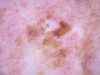

In [5]:
df.iloc[0]['image']

In [6]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image'],
      dtype='object')

In [7]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import  transforms
import torch.nn.functional as F

train_transform = transforms.Compose([
    transforms.ToPILImage(),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor()
])

label_map = {
    'akiec': 0,
    'bcc': 1,
    'bkl': 2,
    'df': 3,
    'mel': 4,
    'nv': 5,
    'vasc': 6
}

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Layer1
    #BatchNorm calcola media e sd per ogni canale e normalizza sui canali, 32 = out_channels
    self.conv1 = nn.Conv2d(3, 48, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(48)

    self.conv2 = nn.Conv2d(48, 48, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(48)

    self.conv3 = nn.Conv2d(48, 96, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(96)

    self.conv4 = nn.Conv2d(96, 96, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(96)

    self.conv5 = nn.Conv2d(96, 192, kernel_size=3, padding=1)
    self.bn5 = nn.BatchNorm2d(192)

    self.conv6 = nn.Conv2d(192, 192, kernel_size=3, padding=1)
    self.bn6 = nn.BatchNorm2d(192)

    self.conv7 = nn.Conv2d(192, 384, kernel_size=3, padding=1)
    self.bn7 = nn.BatchNorm2d(384)

    self.conv8 = nn.Conv2d(384, 384, kernel_size=3, padding=1)
    self.bn8 = nn.BatchNorm2d(384)

    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    self.gap = nn.AdaptiveAvgPool2d((1, 1))

    self.fc = nn.Linear(384, 7)

  def forward(self, x):

    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = self.pool(x)

    x = F.relu(self.bn3(self.conv3(x)))
    x = F.relu(self.bn4(self.conv4(x)))
    x = self.pool(x)

    x = F.relu(self.bn5(self.conv5(x)))
    x = F.relu(self.bn6(self.conv6(x)))
    x = self.pool(x)

    x = F.relu(self.bn7(self.conv7(x)))
    x = F.relu(self.bn8(self.conv8(x)))
    x = self.pool(x)

    x = self.gap(x)

    x = torch.flatten(x, 1)

    x = self.fc(x)

    return x

class ProjectDataset(Dataset):
  def __init__(self, df, label_map, transform=None):
    self.df = df
    self.label_map = label_map
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index):
    image = self.df['image'].iloc[index]
    label = self.df['dx'].iloc[index]
    label = self.label_map[label]

    if self.transform is not None:

      image = self.transform(image)

    else:

      image = torch.tensor(image, dtype = torch.float32)



      image = image.permute(2, 0, 1)

      image = image / 255.0

      label = torch.tensor(label, dtype = torch.long)

    return image, label


In [8]:
# @title
image_try = df['image'].iloc[0]

image_try = torch.tensor(image_try, dtype=torch.float32)

# da (H, W, C) a (C, H, W)
image_try = image_try.permute(2, 0, 1)

# aggiungo la dimensione batch
image_try = image_try.unsqueeze(0)

CNN_try = CNN()

logits_try = CNN_try(image_try)

print(logits_try)

tensor([[-0.8100,  0.0459,  0.0621,  0.3310,  0.5456,  0.9565, -0.5361]],
       grad_fn=<AddmmBackward0>)


In [9]:
# @title
import matplotlib.pyplot as plt

dataset_try = ProjectDataset(df, label_map)

index = 3560

image_try, label = dataset_try[index]

print(label)
print(df['dx'].iloc[index])



tensor(5)
nv


Preparazione del dataset e dei dati di training:

In [19]:
torch.manual_seed(42)
np.random.seed(42)

N_unique = df["lesion_id"].unique().copy()

np.random.shuffle(N_unique)

n_train = int(len(N_unique) * 0.70)
n_test = int(len(N_unique) * 0.85)

train_lesions = N_unique[:n_train]
val_lesions = N_unique[n_train:n_test]
test_lesions = N_unique[n_test:]

train_df = df[
    df["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

val_df = df[
    df["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

test_df = df[
    df["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


train_df_torch = ProjectDataset(train_df, label_map, transform=train_transform)
val_df_torch = ProjectDataset(val_df, label_map)
test_df_torch = ProjectDataset(test_df, label_map)

class_counts = train_df["dx"].value_counts()

weights = len(train_df) / (
    len(class_counts) * class_counts
)

weights = torch.tensor(
    [weights[class_name] for class_name in label_map.keys()],
    dtype=torch.float32
)

# alphas = [0.8, 0.9, 1.0, 1.1, 1.2]
weights = weights**0.85

#Creiamo il modello con la classe CNN
model = CNN()

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.0002
)

print(criterion)
print(criterion.weight)

print(set(train_df["lesion_id"]) & set(val_df["lesion_id"]))
print(set(train_df["lesion_id"]) & set(test_df["lesion_id"]))
print(set(val_df["lesion_id"]) & set(test_df["lesion_id"]))


CrossEntropyLoss()
tensor([3.6259, 2.3579, 1.2392, 8.7537, 1.2460, 0.2699, 6.0697])
set()
set()
set()


In [20]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import balanced_accuracy_score

train_loader = DataLoader(
    train_df_torch,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_df_torch,
    batch_size=32
)

test_loader = DataLoader(
    test_df_torch,
    batch_size=1
)

epochs = 50

best_balanced_acc = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

for epoch in range(epochs):

    # =========================
    # TRAIN
    # =========================

    model.train()

    train_loss = 0.0
    train_total_weight = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}"
    )

    for image, label in progress_bar:

        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()

        logits = model(image)

        current_loss = criterion(logits, label)

        current_loss.backward()

        optimizer.step()

        batch_weight = weights[label].sum().item()

        train_loss += current_loss.item() * batch_weight
        train_total_weight += batch_weight

    train_loss /= train_total_weight


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss = 0.0
    val_total_weight = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for image, label in val_loader:

            image, label = image.to(device), label.to(device)

            logits = model(image)

            current_loss = criterion(logits, label)

            predicted = torch.argmax(logits, dim=1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

            batch_weight = weights[label].sum().item()

            val_loss += current_loss.item() * batch_weight
            val_total_weight += batch_weight

    val_loss /= val_total_weight

    balanced_acc = balanced_accuracy_score(
        all_labels,
        all_preds
    )


    # Salvo il modello che ha l'accuracy bilanciata migliore progressivamente
    if balanced_acc > best_balanced_acc:

      best_balanced_acc = balanced_acc

      torch.save(model.state_dict(), "best_model_balanced.pth")


    # =========================
    # OUTPUT
    # =========================

    print(
        f"Epoch {epoch+1}: "
        f"Train loss = {train_loss:.4f} | "
        f"Val loss = {val_loss:.4f} | "
        f"Val balanced accuracy = {balanced_acc:.4f}"
    )

Epoch 1/50:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 1: Train loss = 1.5711 | Val loss = 1.4871 | Val balanced accuracy = 0.3723


Epoch 2/50:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 2: Train loss = 1.3759 | Val loss = 1.3666 | Val balanced accuracy = 0.4443


Epoch 3/50:   0%|          | 0/220 [00:00<?, ?it/s]

...

Epoch 48: Train loss = 0.6033 | Val loss = 1.1103 | Val balanced accuracy = 0.6560


Epoch 49/50:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 49: Train loss = 0.5639 | Val loss = 1.2397 | Val balanced accuracy = 0.5514


Epoch 50/50:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 50: Train loss = 0.6188 | Val loss = 1.2176 | Val balanced accuracy = 0.6210


In [21]:
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.load_state_dict(
    torch.load("best_model_balanced.pth")
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for image, label in val_loader:

        image, label = image.to(device), label.to(device)

        logits = model(image)

        predicted = torch.argmax(
            logits,
            dim=1
        )

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            label.cpu().numpy()
        )

Rete nuova doppia

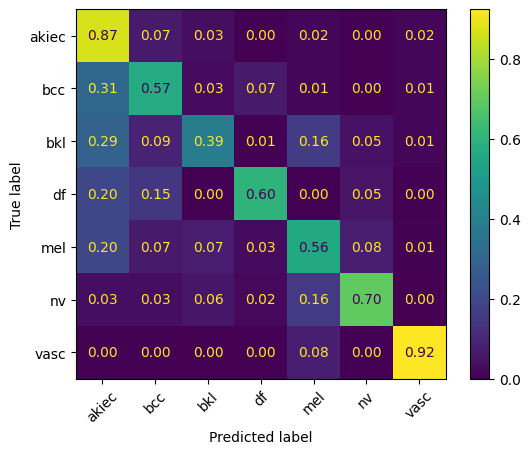

Macro F1: 0.5221430986414474


In [ ]:
from sklearn.metrics import f1_score
BIGcmXL = confusion_matrix(
    all_labels,
    all_preds,
    normalize="true"
)

display = ConfusionMatrixDisplay(
    confusion_matrix=BIGcmXL,
    display_labels=list(label_map.keys())
)

display.plot(
    xticks_rotation=45,
    values_format=".2f"
)

plt.show()

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print("Macro F1:", macro_f1)



weights^0.8

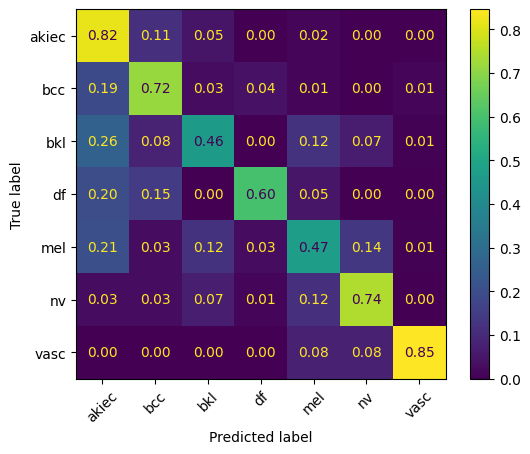

Macro F1: 0.5601231816991927


In [ ]:
from sklearn.metrics import f1_score
BIGcmXL08 = confusion_matrix(
    all_labels,
    all_preds,
    normalize="true"
)

display = ConfusionMatrixDisplay(
    confusion_matrix=BIGcmXL08,
    display_labels=list(label_map.keys())
)

display.plot(
    xticks_rotation=45,
    values_format=".2f"
)

plt.show()

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print("Macro F1:", macro_f1)



Pesi 0.7

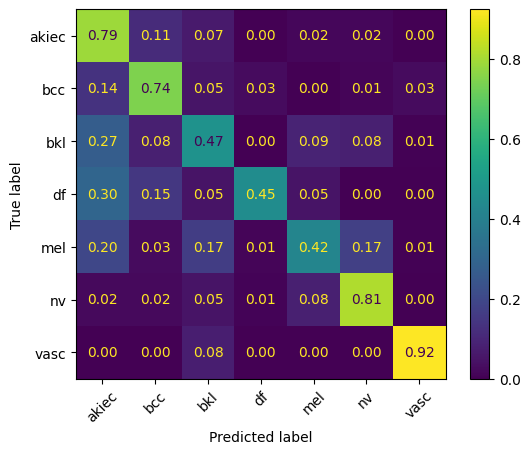

Macro F1: 0.5687613054603444


In [14]:
from sklearn.metrics import f1_score
BIGcmXL07 = confusion_matrix(
    all_labels,
    all_preds,
    normalize="true"
)

display = ConfusionMatrixDisplay(
    confusion_matrix=BIGcmXL07,
    display_labels=list(label_map.keys())
)

display.plot(
    xticks_rotation=45,
    values_format=".2f"
)

plt.show()

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print("Macro F1:", macro_f1)



Pesi^0.9

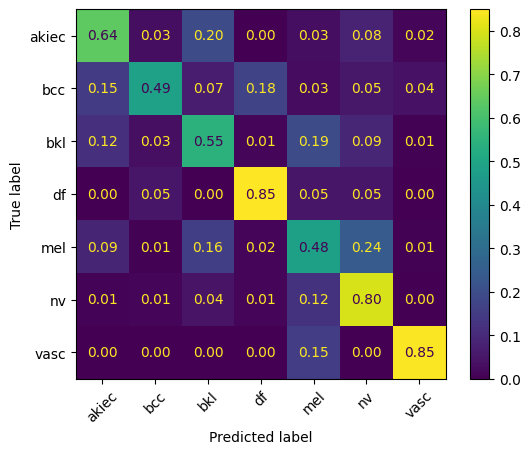

Macro F1: 0.5757213857921205


In [18]:
from sklearn.metrics import f1_score
BIGcmXL09 = confusion_matrix(
    all_labels,
    all_preds,
    normalize="true"
)

display = ConfusionMatrixDisplay(
    confusion_matrix=BIGcmXL09,
    display_labels=list(label_map.keys())
)

display.plot(
    xticks_rotation=45,
    values_format=".2f"
)

plt.show()

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print("Macro F1:", macro_f1)



Pesi a 0.85

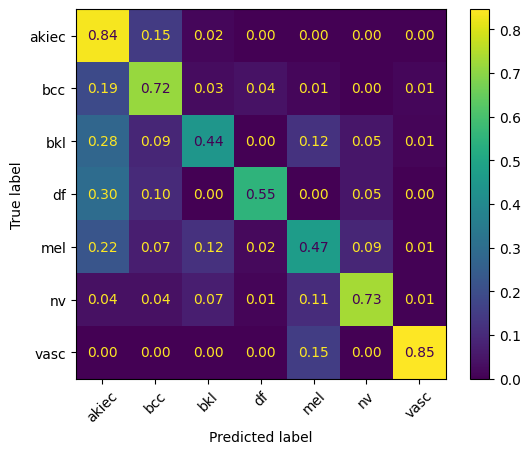

Macro F1: 0.5315007300059935


In [22]:
from sklearn.metrics import f1_score
BIGcmXL085 = confusion_matrix(
    all_labels,
    all_preds,
    normalize="true"
)

display = ConfusionMatrixDisplay(
    confusion_matrix=BIGcmXL085,
    display_labels=list(label_map.keys())
)

display.plot(
    xticks_rotation=45,
    values_format=".2f"
)

plt.show()

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print("Macro F1:", macro_f1)

